In [5]:
import pyodbc

# Replace these with your actual database credentials
server = 'DESKTOP-27LEJGL\KK'  # e.g., 'localhost' or '192.168.1.100'
database = 'abc'  # e.g., 'SalesDB'


# Create a connection string
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database}'

# Try connecting to the databaseimport pyodbc

# Replace with your actual details
server = 'DESKTOP-27LEJGL\KK'
database = 'add'

# Use Trusted Connection (Windows login)
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    print("✅ Connection successful!")

    cursor = conn.cursor()

    # Query to list all tables in the database
    cursor.execute("SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE'")

    print("📋 Tables in the database:")
    for row in cursor.fetchall():
        print("-", row.TABLE_NAME)

    conn.close()

except Exception as e:
    print("❌ Connection failed. Error:", e)

try:
    conn = pyodbc.connect(conn_str)
    print("Connection successful!")
    conn.close()  # Close the connection after testing
except Exception as e:
    print("Connection failed. Error:", e)

✅ Connection successful!
📋 Tables in the database:
- date
- Dim_bac
- Dim_Company
- Dim_Condidat
- Dim_condidature
- Dim_cursus
- Dim_date
- Dim_employer
- Dim_job
- Dim_parent
- Dim_region
- Dim_speciality
- Dim_University
- fact_a
- Fact_employbility
Connection successful!


# Serie temporelle SARIMA

C:\Users\admin\AppData\Local\Temp\ipykernel_7164\3413042368.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)  # Lecture du résultat de la requête dans un DataFrame
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction

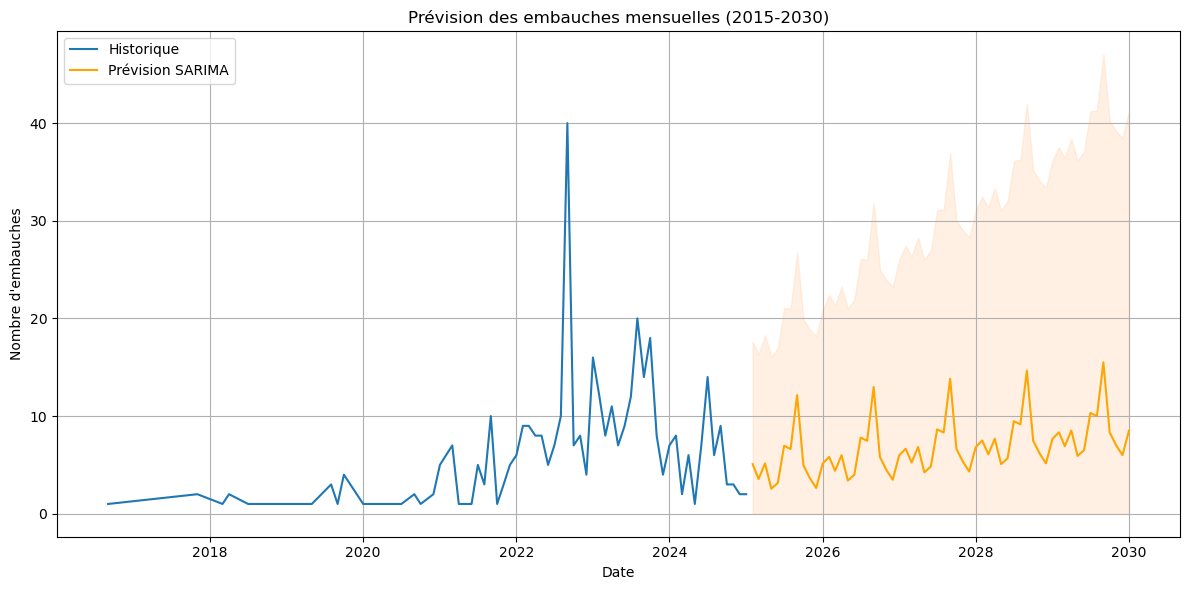

         Date  Prévision  Borne Inf  Borne Sup
0  2025-02-01   5.081883        0.0  17.610892
1  2025-03-01   3.550465        0.0  16.334814
2  2025-04-01   5.156516        0.0  18.287835
3  2025-05-01   2.556173        0.0  16.020919
4  2025-06-01   3.156395        0.0  16.946713
5  2025-07-01   6.956506        0.0  21.064875
6  2025-08-01   6.631179        0.0  20.993575
7  2025-09-01  12.138258        0.0  26.793135
8  2025-10-01   4.971331        0.0  19.917837
9  2025-11-01   3.638034        0.0  18.870385
10 2025-12-01   2.638032        0.0  18.150971
11 2026-01-01   5.137927        0.0  20.926470
12 2026-02-01   5.818329        0.0  22.397614
13 2026-03-01   4.396431        0.0  21.313821
14 2026-04-01   5.997423        0.0  23.261639
15 2026-05-01   3.397384        0.0  21.000901
16 2026-06-01   3.997422        0.0  21.933855
17 2026-07-01   7.797431        0.0  26.060708
18 2026-08-01   7.472350        0.0  26.058269
19 2026-09-01  12.979510        0.0  31.855128
20 2026-10-01

In [6]:
# Importation des bibliothèques nécessaires
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX  # Pour le modèle SARIMA

# Connexion à la base de données SQL Server
conn_str = 'DRIVER={SQL Server};SERVER=DESKTOP-27LEJGL\\KK;DATABASE=abc;Trusted_Connection=yes;'
conn = pyodbc.connect(conn_str)

# Requête SQL pour récupérer les dates d'embauche à partir de 2015
query = """
SELECT 
    FORMAT(position_date_3_333, 'yyyy-MM-01') AS hire_month
FROM Dim_employer
WHERE position_date_3_333 IS NOT NULL AND position_date_3_333 >= '2015-01-01'
"""
df = pd.read_sql(query, conn)  # Lecture du résultat de la requête dans un DataFrame
conn.close()  # Fermeture de la connexion à la base de données

# Conversion des dates au format datetime
df['hire_month'] = pd.to_datetime(df['hire_month'])

# Agrégation : compter le nombre d'embauches par mois
df_grouped = df.groupby('hire_month').size().reset_index(name='hired_students')

# Mise en index sur la colonne date pour faciliter l'analyse temporelle
df_grouped.set_index('hire_month', inplace=True)

# Définition et entraînement du modèle SARIMA
model = SARIMAX(df_grouped,
                order=(1, 1, 1),  # Paramètres ARIMA : (p,d,q)
                seasonal_order=(1, 1, 1, 12),  # Paramètres saisonniers (P,D,Q,s) avec s=12 pour les mois
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit(disp=False)  # Entraînement du modèle sans afficher les détails

# Calcul du nombre de mois à prédire jusqu'à janvier 2030
last_date = df_grouped.index[-1]  # Dernière date connue
end_date = pd.to_datetime("2030-01-01")
months_to_predict = (end_date.year - last_date.year) * 12 + (end_date.month - last_date.month)

# Génération des dates futures pour les prédictions
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=months_to_predict, freq='MS')

# Génération des prévisions
forecast_result = model_fit.get_forecast(steps=months_to_predict)
forecast = forecast_result.predicted_mean.clip(lower=0)  # Évite les valeurs négatives
conf_int = forecast_result.conf_int().clip(lower=0)  # Intervalle de confiance avec minimum 0

# Visualisation des résultats
plt.figure(figsize=(12, 6))
plt.plot(df_grouped, label='Historique')  # Série réelle
plt.plot(forecast_dates, forecast, label='Prévision SARIMA', color='orange')  # Série prédite
plt.fill_between(forecast_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='peachpuff', alpha=0.4)  # Intervalle de confiance
plt.title("Prévision des embauches mensuelles (2015-2030)")
plt.xlabel("Date")
plt.ylabel("Nombre d'embauches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Affichage des résultats sous forme de tableau
result_df = pd.DataFrame({
    'Date': forecast_dates,
    'Prévision': forecast.values,
    'Borne Inf': conf_int.iloc[:, 0].values,
    'Borne Sup': conf_int.iloc[:, 1].values
})
print(result_df)


# Serie temporelle LSTM

C:\Users\admin\AppData\Local\Temp\ipykernel_7164\364959422.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


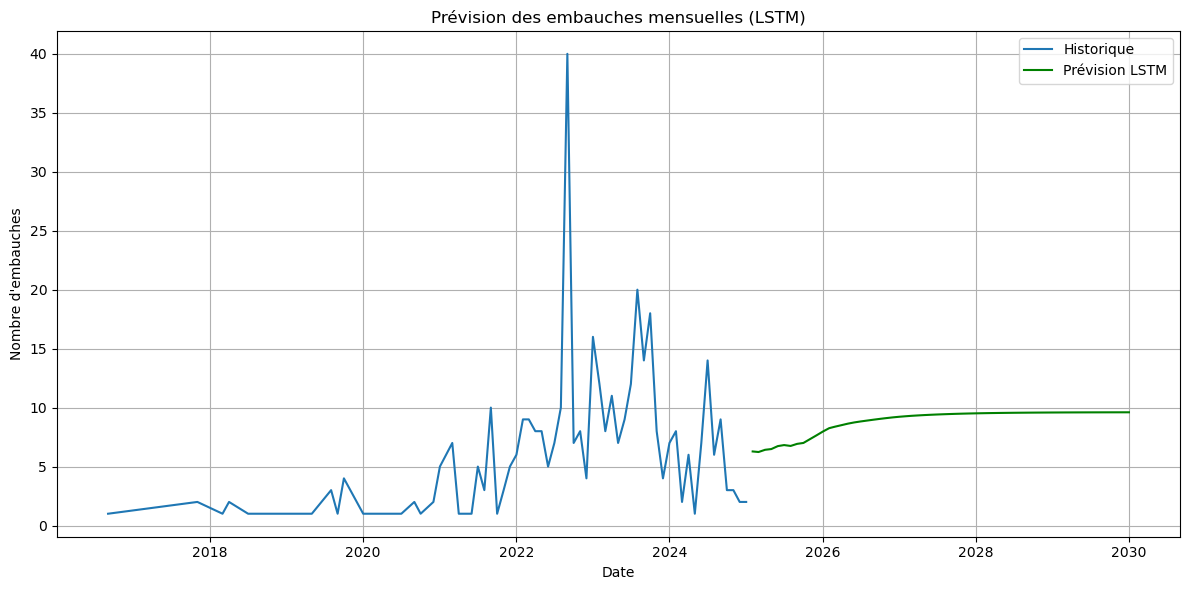

         Date  Prévision
0  2025-02-01   6.280416
1  2025-03-01   6.233567
2  2025-04-01   6.420958
3  2025-05-01   6.484361
4  2025-06-01   6.734342
5  2025-07-01   6.821998
6  2025-08-01   6.747940
7  2025-09-01   6.924039
8  2025-10-01   7.002080
9  2025-11-01   7.322081
10 2025-12-01   7.631192
11 2026-01-01   7.960030
12 2026-02-01   8.255915
13 2026-03-01   8.383665
14 2026-04-01   8.511897
15 2026-05-01   8.637851
16 2026-06-01   8.743646
17 2026-07-01   8.825204
18 2026-08-01   8.900484
19 2026-09-01   8.975321
20 2026-10-01   9.044138
21 2026-11-01   9.110196
22 2026-12-01   9.169823
23 2027-01-01   9.222402
24 2027-02-01   9.266627
25 2027-03-01   9.303148
26 2027-04-01   9.336205
27 2027-05-01   9.365842
28 2027-06-01   9.392068
29 2027-07-01   9.415381
30 2027-08-01   9.436438
31 2027-09-01   9.455437
32 2027-10-01   9.472428
33 2027-11-01   9.487589
34 2027-12-01   9.501005
35 2028-01-01   9.512840
36 2028-02-01   9.523263
37 2028-03-01   9.532492
38 2028-04-01   9.540730


In [7]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler  # Pour normaliser les données
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense  # Réseau de neurones LSTM

# Connexion à la base de données SQL Server
conn_str = 'DRIVER={SQL Server};SERVER=DESKTOP-27LEJGL\\KK;DATABASE=abc;Trusted_Connection=yes;'
conn = pyodbc.connect(conn_str)

# Requête SQL pour extraire les dates d'embauche à partir de 2015
query = """
SELECT 
    FORMAT(position_date_3_333, 'yyyy-MM-01') AS hire_month
FROM Dim_employer
WHERE position_date_3_333 IS NOT NULL AND position_date_3_333 >= '2015-01-01'
"""
df = pd.read_sql(query, conn)
conn.close()  # On ferme la connexion une fois les données chargées

# Prétraitement des données
df['hire_month'] = pd.to_datetime(df['hire_month'])  # Conversion des dates
df_grouped = df.groupby('hire_month').size().reset_index(name='hired_students')  # Agrégation par mois
df_grouped.set_index('hire_month', inplace=True)  # Indexation par date

data = df_grouped['hired_students'].values.reshape(-1, 1)  # Extraction des valeurs sous forme de vecteur colonne

# Normalisation des données (important pour LSTM)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Création des séquences de données pour l'apprentissage (X = 12 mois, y = valeur suivante)
X, y = [], []
n_steps = 12  # Longueur de la séquence = 12 mois
for i in range(n_steps, len(data_scaled)):
    X.append(data_scaled[i-n_steps:i, 0])  # séquence de 12 mois
    y.append(data_scaled[i, 0])            # valeur cible (le 13ème mois)
X, y = np.array(X), np.array(y)

# Reshape pour LSTM : (nombre d'échantillons, pas de temps, 1 variable)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Définition du modèle LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))  # 50 neurones, fonction d’activation relu
model.add(Dense(1))  # Couche de sortie : une seule valeur prédite
model.compile(optimizer='adam', loss='mse')  # Optimiseur Adam, perte = erreur quadratique moyenne
model.fit(X, y, epochs=100, verbose=0)  # Entraînement sur 100 époques (cycles)

# Prédiction du futur jusqu’à 2030
# Calcul du nombre de mois à prédire
future_months = (2030 - df_grouped.index[-1].year) * 12 + (1 - df_grouped.index[-1].month)

# Séquence initiale = les 12 derniers mois connus
input_seq = data_scaled[-n_steps:]
predictions = []

# Génération des prévisions mois par mois
for _ in range(future_months):
    input_reshaped = input_seq.reshape((1, n_steps, 1))  # Reshape pour LSTM
    pred = model.predict(input_reshaped, verbose=0)  # Prédiction du mois suivant
    predictions.append(pred[0][0])  # Stockage du résultat
    input_seq = np.append(input_seq[1:], pred[0][0])  # Ajout du résultat à la séquence

# Inverse de la normalisation pour revenir aux vraies valeurs
forecast_scaled = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Création des dates futures
forecast_dates = pd.date_range(start=df_grouped.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='MS')

# Visualisation du résultat
plt.figure(figsize=(12, 6))
plt.plot(df_grouped.index, df_grouped['hired_students'], label='Historique')  # Série réelle
plt.plot(forecast_dates, forecast_scaled, label='Prévision LSTM', color='green')  # Série prédite
plt.title('Prévision des embauches mensuelles (LSTM)')
plt.xlabel('Date')
plt.ylabel("Nombre d'embauches")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Tableau des résultats de la prévision
result_lstm = pd.DataFrame({
    'Date': forecast_dates,
    'Prévision': forecast_scaled.flatten()
})
print(result_lstm)


# Serie temporelle RNN

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


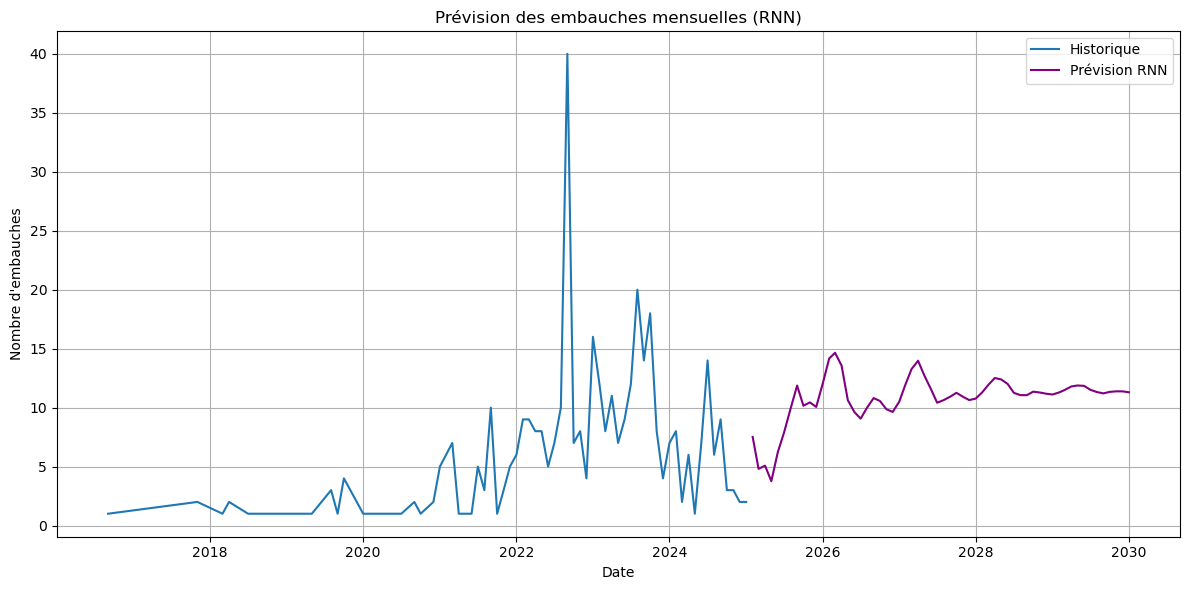

         Date  Prévision
0  2025-02-01   7.515350
1  2025-03-01   4.805037
2  2025-04-01   5.075249
3  2025-05-01   3.762099
4  2025-06-01   6.227065
5  2025-07-01   7.905669
6  2025-08-01   9.923319
7  2025-09-01  11.868752
8  2025-10-01  10.159585
9  2025-11-01  10.441530
10 2025-12-01  10.055943
11 2026-01-01  12.016370
12 2026-02-01  14.165833
13 2026-03-01  14.647754
14 2026-04-01  13.565208
15 2026-05-01  10.623000
16 2026-06-01   9.631642
17 2026-07-01   9.061263
18 2026-08-01  10.004218
19 2026-09-01  10.808127
20 2026-10-01  10.563185
21 2026-11-01   9.862075
22 2026-12-01   9.633927
23 2027-01-01  10.494746
24 2027-02-01  12.015461
25 2027-03-01  13.270900
26 2027-04-01  13.973553
27 2027-05-01  12.713902
28 2027-06-01  11.583381
29 2027-07-01  10.413682
30 2027-08-01  10.634542
31 2027-09-01  10.925344
32 2027-10-01  11.254394
33 2027-11-01  10.919310
34 2027-12-01  10.638040
35 2028-01-01  10.763427
36 2028-02-01  11.294924
37 2028-03-01  11.923079
38 2028-04-01  12.508533


In [8]:
# Importation des bibliothèques nécessaires
from tensorflow.keras.layers import SimpleRNN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Modèle RNN
# On utilise un modèle séquentiel avec une couche RNN simple et une couche Dense pour la sortie
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(n_steps, 1)))  # Couche RNN avec 50 unités et fonction d'activation ReLU
model_rnn.add(Dense(1))  # Couche de sortie : une seule valeur prédite (nombre d'embauches)
model_rnn.compile(optimizer='adam', loss='mse')  # Compilation du modèle avec l'optimiseur Adam et l'erreur quadratique moyenne comme fonction de perte
model_rnn.fit(X, y, epochs=100, verbose=0)  # Entraînement du modèle sur 100 époques

# Prévision RNN
# On commence la prévision à partir des 12 dernières valeurs connues (normalisées)
input_seq = data_scaled[-n_steps:]
predictions_rnn = []

# On prédit mois par mois jusqu'à 2030
for _ in range(future_months):
    input_reshaped = input_seq.reshape((1, n_steps, 1))  # Reshape pour correspondre à la forme attendue par le modèle
    pred = model_rnn.predict(input_reshaped, verbose=0)  # Prédiction pour le mois suivant
    predictions_rnn.append(pred[0][0])  # On ajoute la prédiction à la liste
    input_seq = np.append(input_seq[1:], pred[0][0])  # On décale la fenêtre et ajoute la prédiction à la fin

# Inverse transformation pour revenir aux vraies valeurs d'embauches
forecast_rnn_scaled = scaler.inverse_transform(np.array(predictions_rnn).reshape(-1, 1))

# Visualisation des résultats
plt.figure(figsize=(12, 6))
plt.plot(df_grouped.index, df_grouped['hired_students'], label='Historique')  # Série historique
plt.plot(forecast_dates, forecast_rnn_scaled, label='Prévision RNN', color='purple')  # Série prédite par RNN
plt.title('Prévision des embauches mensuelles (RNN)')
plt.xlabel('Date')
plt.ylabel("Nombre d'embauches")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Affichage des résultats dans un tableau
result_rnn = pd.DataFrame({
    'Date': forecast_dates,
    'Prévision': forecast_rnn_scaled.flatten()  # Aplatir le tableau pour qu’il soit lisible
})
print(result_rnn)


# Comparaison entre les modeles

C:\Users\admin\AppData\Local\Temp\ipykernel_6696\1158367223.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RMSE SARIMA : 5.43


C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE LSTM : 5.66


C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE RNN : 1.90

✅ Le modèle le plus performant est : RNN (RMSE = 1.90)


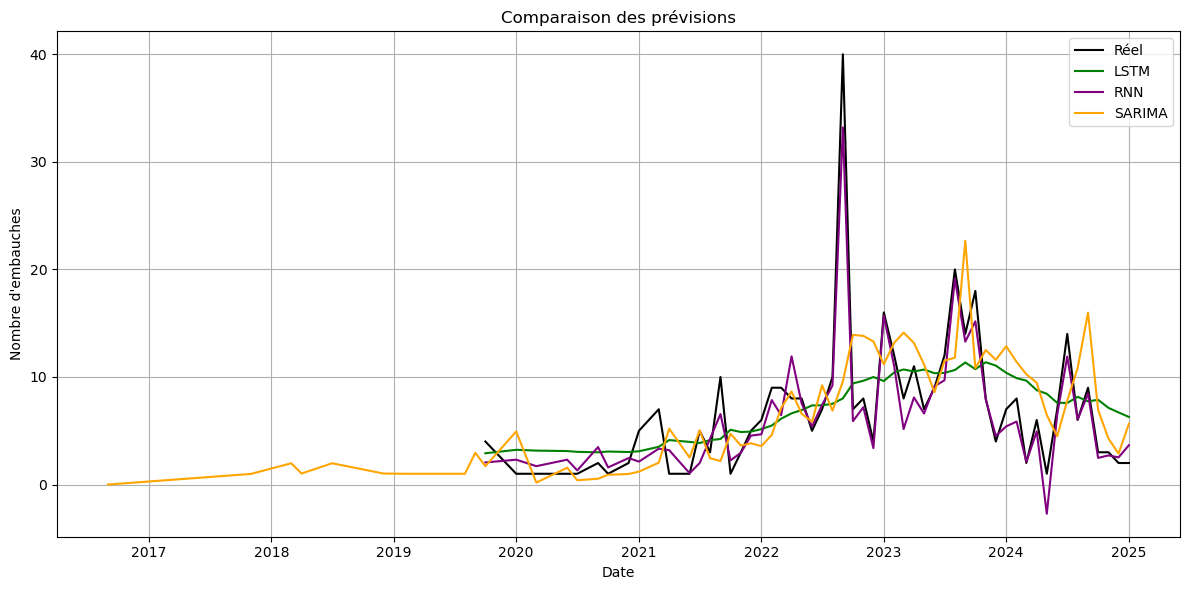

In [24]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Connexion SQL
conn_str = 'DRIVER={SQL Server};SERVER=DESKTOP-27LEJGL\\KK;DATABASE=abc;Trusted_Connection=yes;'
conn = pyodbc.connect(conn_str)

query = """
SELECT 
    FORMAT(position_date_3_333, 'yyyy-MM-01') AS hire_month
FROM Dim_employer
WHERE position_date_3_333 IS NOT NULL AND position_date_3_333 >= '2015-01-01'
"""
df = pd.read_sql(query, conn)
conn.close()

# Préparation des données
df['hire_month'] = pd.to_datetime(df['hire_month'])
df_grouped = df.groupby('hire_month').size().reset_index(name='hired_students')
df_grouped.set_index('hire_month', inplace=True)
original = df_grouped.copy()

# ----------------- SARIMA -----------------
model_sarima = SARIMAX(df_grouped, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = model_sarima.fit(disp=False)

forecast_sarima = sarima_fit.predict(start=0, end=len(df_grouped)-1, typ='levels')
rmse_sarima = sqrt(mean_squared_error(df_grouped.values, forecast_sarima))
print(f"RMSE SARIMA : {rmse_sarima:.2f}")

# ----------------- Préparation pour LSTM / RNN -----------------
data = df_grouped['hired_students'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

n_steps = 12
X, y = [], []
for i in range(n_steps, len(data_scaled)):
    X.append(data_scaled[i-n_steps:i, 0])
    y.append(data_scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# ----------------- LSTM -----------------
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X, y, epochs=100, verbose=0)

pred_lstm = model_lstm.predict(X, verbose=0)
pred_lstm_rescaled = scaler.inverse_transform(pred_lstm)
true_lstm_rescaled = scaler.inverse_transform(y.reshape(-1, 1))
rmse_lstm = sqrt(mean_squared_error(true_lstm_rescaled, pred_lstm_rescaled))
print(f"RMSE LSTM : {rmse_lstm:.2f}")

# ----------------- RNN -----------------
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(n_steps, 1)))
model_rnn.add(Dense(1))
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X, y, epochs=100, verbose=0)

pred_rnn = model_rnn.predict(X, verbose=0)
pred_rnn_rescaled = scaler.inverse_transform(pred_rnn)
rmse_rnn = sqrt(mean_squared_error(true_lstm_rescaled, pred_rnn_rescaled))
print(f"RMSE RNN : {rmse_rnn:.2f}")

# ----------------- Comparaison -----------------
results = {
    'SARIMA': rmse_sarima,
    'LSTM': rmse_lstm,
    'RNN': rmse_rnn
}
best_model = min(results, key=results.get)
print(f"\n✅ Le modèle le plus performant est : {best_model} (RMSE = {results[best_model]:.2f})")

# ----------------- Affichage visuel -----------------
plt.figure(figsize=(12,6))
plt.plot(df_grouped.index[n_steps:], true_lstm_rescaled, label='Réel', color='black')
plt.plot(df_grouped.index[n_steps:], pred_lstm_rescaled, label='LSTM', color='green')
plt.plot(df_grouped.index[n_steps:], pred_rnn_rescaled, label='RNN', color='purple')
plt.plot(df_grouped.index, forecast_sarima, label='SARIMA', color='orange')
plt.title("Comparaison des prévisions")
plt.xlabel("Date")
plt.ylabel("Nombre d'embauches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
pip install imbalanced-learn  


  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/9d/41/721fec82606242a2072ee909086ff918dfad7d0199a9dfd4928df9c72494/imbalanced_learn-0.13.0-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<1,>=0.1 from https://files.pythonhosted.org/packages/f0/a8/ad69cf130fbd017660cdd64abbef3f28135d9e2e15fe3002e03c5be0ca38/sklearn_compat-0.1.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/238.4 kB ? eta -:--:--
   -------- ------------------------------- 51.2/238.4 kB 1.3 MB/s eta 0:00:01
   ------------------------ --------------- 143.4/238.4 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 238.4/238.4 kB 2.1 MB/s eta 0:00:00
